# OCR text detection practice

This section will introduce how to use PaddleOCR to complete the training and operation of the text detection DB algorithm, including:
1. Quickly call PaddleOCR package to experience text detection
2. Understand the principle of text detection DB algorithm
3. Master the text detection model construction process
4. Master the text detection model training process

Note: `paddleocr` refers to `PaddleOCR whl package`.


# 2. Detailed Implementation of DB Text Detection Algorithm


## 2.1 DB Text Detection Algorithm Principle


[DB](https://arxiv.org/pdf/1911.08947.pdf) is a segmentation-based text detection algorithm, which proposes a Differentiable Threshold Differentiable Binarization module (DB module) that uses a dynamic threshold to distinguish the text area from the background.


<center><img src="https://ai-studio-static-online.cdn.bcebos.com/5eabdb59916a4267a049e5440f5093a63b6bfac9010844fb971aad0607d455a1" width = "600"></center>
<center><br>Figure 2: The difference between DB model and other methods</br></center>
<br></br>

The process of the segmentation-based ordinary text detection algorithm is shown by the blue arrow in the above figure. After this method obtains the segmentation result, a fixed threshold is used to obtain the binarized segmentation map, and then heuristic algorithms such as pixel clustering are used to obtain Text area.

The flow of the DB algorithm is shown by the red arrow in the figure. The biggest difference is that DB has a threshold map, which uses the network to predict the threshold at each position of the picture, instead of using a fixed value to better separate the text background and the foreground. .

The DB algorithm has the following advantages:
1. The algorithm structure is simple, without tedious post-processing
2. Have good accuracy and performance on open source data


In the traditional image segmentation algorithm, after obtaining the probability map, the standard binarize method is used for processing. The pixels below the threshold are set to 0, and the pixels above the threshold are set to 1. The formula is as follows:
$$ B_{i,j}=\left\{
\begin{aligned}
1, if P_{i,j} >= t ,\\
0, otherwise.
\end{aligned}
\right.
$$
But the standard binarization method is not differentiable, making the network unable to train end-to-end. To solve this problem, the DB algorithm proposes Differentiable Binarization (DB). Differentiable binarization approximates the step function in standard binarization, using the following formula to replace:
$$
\hat{B} = \frac{1}{1 + e^{-k(P_{i,j}-T_{i,j})}}
$$
Among them, P is the probability map obtained above, T is the threshold map obtained above, and k is the gain factor. In the experiment, it is selected as 50 based on experience. The comparison chart of standard binarization and differentiable binarization is shown in **Figure 2(a)** below.

When using cross-entropy loss, the loss of positive and negative samples are $l_+$ and $l_-$ respectively:
$$
l_+ = -log(\frac{1}{1 + e^{-k(P_{i,j}-T_{i,j})}})
$$
$$
l_- = -log(1-\frac{1}{1 + e^{-k(P_{i,j}-T_{i,j})}})
$$
Taking the partial derivative of the input $x$ will give:
$$
\frac{\delta{l_+}}{\delta{x}} = -kf(x)e^{-kx}
$$
$$
\frac{\delta{l_-}}{\delta{x}} = -kf(x)
$$
It can be found that the enhancement factor will amplify the gradient of the error prediction, thereby optimizing the model to obtain better results. **Figure 2(b)**, the part of $x<0$ is the case where positive samples are predicted to be negative samples. It can be seen that the gain factor k amplifies the gradient; while **Figure 2(c)** The part where $x>0$ is a negative sample is predicted to be a positive sample, the gradient is also magnified.

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/29255d870bd74403af37c8f88cb10ebca0c3117282614774a3d607efc8be8c84" width = "600"></center>
<center><br>Figure 3: Schematic diagram of DB algorithm</br></center>
<br></br>



The overall structure of the DB algorithm is shown in the figure below:

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/6e1f293e9a1f4c90b6c26919f16b95a4a85dcf7be73f4cc99c9dc5477bb956e6" width = "1000"></center>
<center><br>Figure 4: Schematic diagram of DB model network structure</br></center>
<br></br>

The input image is extracted through the network Backbone and FPN to extract features, and the extracted features are cascaded together to obtain a quarter-size feature of the original image. Then, the convolutional layer is used to obtain the text area prediction probability map and the threshold map respectively, and then through the DB The post-processing to get the text enclosing curve.


In [1]:
# For the first run, you need to open the comment on the next line and download the PaddleOCR code
#!git clone https://gitee.com/paddlepaddle/PaddleOCR
import os
# Modify the default directory where the code runs to /home/aistudio/PaddleOCR
os.chdir("PaddleOCR")

In [2]:
!pwd

/home/loc/Workspace/ocr-exp/PaddleOCR


## 2.2 DB Text Detection Model Construction


The DB text detection model can be divided into three parts:
- Backbone network, responsible for extracting image features
- FPN network, feature pyramid structure enhanced features
- Head network, calculate the probability map of the text area

In this section, PaddlePaddle is used to implement the above three network modules and complete the complete network construction.


**backbone network**

The Backbone part of the DB text detection network uses an image classification network. In the paper, ResNet50 is used. In this section of the experiment, in order to speed up the training, the MobileNetV3 large structure is used as the backbone.

In [5]:
import paddle

In [6]:
#  https://github.com/PaddlePaddle/PaddleOCR/blob/release%2F2.4/ppocr/modeling/backbones/det_mobilenet_v3.py
from ppocr.modeling.backbones.det_mobilenet_v3 import MobileNetV3

In [7]:
fake_inputs = paddle.randn([1, 3, 640, 640], dtype="float32")
fake_inputs

Tensor(shape=[1, 3, 640, 640], dtype=float32, place=Place(cpu), stop_gradient=True,
       [[[[ 1.16616976,  0.35036972,  0.32974282, ..., -0.41971010,
           -1.19134438,  0.44726235],
          [-0.57908225, -1.64556873, -0.98241973, ..., -0.56509465,
           -0.75241089, -0.22634481],
          [-0.13025874, -0.56110233,  0.56464696, ..., -2.05701947,
           -0.29718521,  0.20024525],
          ...,
          [-1.06532156, -1.51476252,  1.35776281, ...,  0.77405125,
            0.78316534, -0.36049041],
          [-0.36442623, -2.04418993,  0.43150899, ...,  1.42989719,
           -0.41802701, -2.94002938],
          [ 0.33416849,  1.05682850, -0.53577733, ..., -2.23435473,
            0.48662806,  1.59341323]],

         [[ 0.01056044, -0.31772342,  1.45841861, ...,  0.50442308,
            0.67484373, -1.13849235],
          [-0.02765056, -0.36138898,  0.99480605, ...,  0.34416619,
            0.00389876, -0.78889298],
          [ 0.12114421, -0.59436846,  0.96208435, .

In [8]:
# 1. Declare Backbone
model_backbone = MobileNetV3()
model_backbone.eval()

In [9]:
# 2. Perform prediction
outs = model_backbone(fake_inputs)

In [13]:
outs

[Tensor(shape=[1, 16, 160, 160], dtype=float32, place=Place(cpu), stop_gradient=False,
        [[[[-0.05456023, -0.08459296, -0.03491466, ...,  0.02692684,
             0.10342828, -0.03479581],
           [ 0.04008822,  0.05243853,  0.00572706, ..., -0.01266714,
            -0.00887943, -0.03809920],
           [-0.14466886, -0.10399660,  0.03800252, ...,  0.12734792,
             0.12597369,  0.13642351],
           ...,
           [ 0.02900271, -0.09467293,  0.17511719, ...,  0.16662961,
             0.15875661, -0.25205642],
           [-0.02427444,  0.06431450,  0.18440132, ..., -0.04237526,
            -0.00221204,  0.20161209],
           [ 0.00901088,  0.01695596, -0.01236324, ..., -0.06662174,
             0.17644832,  0.07715350]],
 
          [[ 0.11487264,  0.40014750, -0.00242290, ...,  0.10180131,
             0.56879276,  0.21629186],
           [ 0.11883361,  0.04857349,  0.01084079, ...,  0.33654231,
             0.53180039,  0.41968855],
           [ 0.13767393,  0.41

In [11]:
# 3. Print network structure
print(model_backbone)

MobileNetV3(
  (conv): ConvBNLayer(
    (conv): Conv2D(3, 8, kernel_size=[3, 3], stride=[2, 2], padding=1, data_format=NCHW)
    (bn): BatchNorm()
  )
  (stage0): Sequential(
    (0): ResidualUnit(
      (expand_conv): ConvBNLayer(
        (conv): Conv2D(8, 8, kernel_size=[1, 1], data_format=NCHW)
        (bn): BatchNorm()
      )
      (bottleneck_conv): ConvBNLayer(
        (conv): Conv2D(8, 8, kernel_size=[3, 3], padding=1, groups=8, data_format=NCHW)
        (bn): BatchNorm()
      )
      (linear_conv): ConvBNLayer(
        (conv): Conv2D(8, 8, kernel_size=[1, 1], data_format=NCHW)
        (bn): BatchNorm()
      )
    )
    (1): ResidualUnit(
      (expand_conv): ConvBNLayer(
        (conv): Conv2D(8, 32, kernel_size=[1, 1], data_format=NCHW)
        (bn): BatchNorm()
      )
      (bottleneck_conv): ConvBNLayer(
        (conv): Conv2D(32, 32, kernel_size=[3, 3], stride=[2, 2], padding=1, groups=32, data_format=NCHW)
        (bn): BatchNorm()
      )
      (linear_conv): ConvBNLa

In [12]:
# 4. Print out the characteristic shape
for idx, out in enumerate(outs):
     print("The index is ", idx, "and the shape of output is ", out.shape)

The index is  0 and the shape of output is  [1, 16, 160, 160]
The index is  1 and the shape of output is  [1, 24, 80, 80]
The index is  2 and the shape of output is  [1, 56, 40, 40]
The index is  3 and the shape of output is  [1, 480, 20, 20]


**FPN Network**

Feature pyramid structure FPN is a common method for convolutional networks to efficiently extract features of each dimension in a picture.

The input of the FPN network is the output of the Backbone part, and the height and width of the output feature map are one-fourth of the original image. Assuming that the shape of the input image is [1, 3, 640, 640], the height and width of the FPN output feature are [160, 160].

In [18]:
import paddle 

# 1. Import DBFPN from PaddleOCR
from ppocr.modeling.necks.db_fpn import DBFPN

# 2. Obtain Backbone network output results
fake_inputs = paddle.randn([1, 3, 640, 640], dtype="float32")
model_backbone = MobileNetV3()
in_channles = model_backbone.out_channels

# 3. Declare FPN network
model_fpn = DBFPN(in_channels=in_channles, out_channels=256)

# 4. Print FPN network
print(model_fpn)

# 5. Calculate FPN result output
outs = model_backbone(fake_inputs)
fpn_outs = model_fpn(outs)

# 6. Print FPN output characteristic shape
print(f"The shape of fpn outs {fpn_outs.shape}")

DBFPN(
  (in2_conv): Conv2D(16, 256, kernel_size=[1, 1], data_format=NCHW)
  (in3_conv): Conv2D(24, 256, kernel_size=[1, 1], data_format=NCHW)
  (in4_conv): Conv2D(56, 256, kernel_size=[1, 1], data_format=NCHW)
  (in5_conv): Conv2D(480, 256, kernel_size=[1, 1], data_format=NCHW)
  (p5_conv): Conv2D(256, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
  (p4_conv): Conv2D(256, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
  (p3_conv): Conv2D(256, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
  (p2_conv): Conv2D(256, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
)
The shape of fpn outs [1, 256, 160, 160]


**Head Network**

Calculate the text area probability map, the text area threshold map and the text area binary map.

The DB Head network will perform up-sampling on the basis of the FPN feature, and map the FPN feature from a quarter of the size of the original image to the size of the original image.

In [20]:
# 1. Imort DBHead from PaddleOCR
from ppocr.modeling.heads.det_db_head import DBHead
import paddle 

# 2. Calculate DBFPN network output results
fake_inputs = paddle.randn([1, 3, 640, 640], dtype="float32")
model_backbone = MobileNetV3()
in_channles = model_backbone.out_channels
model_fpn = DBFPN(in_channels=in_channles, out_channels=256)
outs = model_backbone(fake_inputs)
fpn_outs = model_fpn(outs)

# 3. Declare Head network
model_db_head = DBHead(in_channels=256)

# 4. Print DBhead network
print(model_db_head)

# 5. Calculate the output of the Head network
db_head_outs = model_db_head(fpn_outs)
print(f"The shape of fpn outs {fpn_outs.shape}")
print(f"The shape of DB head outs {db_head_outs['maps'].shape}")


DBHead(
  (binarize): Head(
    (conv1): Conv2D(256, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
    (conv_bn1): BatchNorm()
    (conv2): Conv2DTranspose(64, 64, kernel_size=[2, 2], stride=[2, 2], data_format=NCHW)
    (conv_bn2): BatchNorm()
    (conv3): Conv2DTranspose(64, 1, kernel_size=[2, 2], stride=[2, 2], data_format=NCHW)
  )
  (thresh): Head(
    (conv1): Conv2D(256, 64, kernel_size=[3, 3], padding=1, data_format=NCHW)
    (conv_bn1): BatchNorm()
    (conv2): Conv2DTranspose(64, 64, kernel_size=[2, 2], stride=[2, 2], data_format=NCHW)
    (conv_bn2): BatchNorm()
    (conv3): Conv2DTranspose(64, 1, kernel_size=[2, 2], stride=[2, 2], data_format=NCHW)
  )
)
The shape of fpn outs [1, 256, 160, 160]
The shape of DB head outs [1, 3, 640, 640]


# 3 Train the DB Text Detection Model
PaddleOCR provides DB text detection algorithms, supports two backbone networks, MobileNetV3 and ResNet50_vd. You can select the corresponding configuration file and start training according to your needs.

This section takes the icdar15 dataset and MobileNetV3 as the backbone network DB detection model (that is, the configuration used by the ultra-lightweight model) as an example to introduce how to complete the training, evaluation and testing of the PaddleOCR Chinese text detection model.

## 3.1 Data Preparation

This experiment selected ICDAR2015, the most well-known and commonly used data set for Scene Text Detection and Recognition tasks. The schematic diagram of the icdar2015 data set is shown in the figure below:

<center><img src="https://ai-studio-static-online.cdn.bcebos.com/e1b06e0c8e904a2aa412e9eea41f45cce3d58543232948fa88200298fd3cd2e4" width = "600"></center>
<center><br>Figure 5: icdar2015 data set schematic diagram </br></center>
<br></br>

The icdar2015 data set has been downloaded in this project and stored in /home/aistudio/data/data96799. You can run the following command to decompress the data set, or download it yourself from the link.
[link download](https://rrc.cvc.uab.es/?ch=4&com=downloads)

After running the above command, ~/train_data/icdar2015/text_localization has two folders and two files, which are:
```
~/train_data/icdar2015/text_localization
  └─ Training data of icdar_c4_train_imgs/ icdar dataset
  └─ ch4_test_images/ test data of icdar data set
  └─ train_icdar2015_label.txt icdar data set training label
  └─ test_icdar2015_label.txt icdar data set test label
```
The format of the annotation file provided is:
```
"Image file name json.dumps encoded image annotation information"
ch4_test_images/img_61.jpg [{"transcription": "MASA", "points": [[310, 104], [416, 141], [418, 216], [312, 179]], ...}]
```

The image annotation information before json.dumps encoding is a list containing multiple dictionaries. The points in the dictionary represent the coordinates (x, y) of the four points of the text box, which are arranged clockwise from the point in the upper left corner. The field in transcription represents the text of the current text box, and this information is not needed in the text detection task. If you want to train PaddleOCR on other data sets, you can construct the annotation file in the above form.

If the text in the "transcription" field is '*' or '###', it means that the corresponding annotation can be ignored. Therefore, if there is no text label, the transcription field can be set to an empty string.


In [36]:
ls icdar2015

ch4_test_images/      test_icdar2015_label.txt
icdar_c4_train_imgs/  train_icdar2015_label.txt


## 3.2 Data Preprocessing

During training, there are certain requirements for the format and size of the input picture. At the same time, it is also necessary to obtain the true label of the threshold map and the probability map according to the labeling information. Therefore, before the data is input to the model, the data needs to be preprocessed to make the pictures and labels meet the needs of network training and prediction. In addition, in order to expand the training data set, suppress over-fitting, and improve the generalization ability of the model, several basic data augmentation methods need to be used.

The data preprocessing of this experiment includes the following methods:

-Image decoding: convert the image to Numpy format;
-Label encoding: parse the label information in the txt file and save it in a unified format;
-Basic data augmentation: including: random horizontal flip, random rotation, random zoom, random crop, etc.;
-Obtain threshold map label: use the expansion method to obtain the threshold map label required for algorithm training;
-Obtain the probability map label: use the shrinking method to obtain the probability map label required for algorithm training;
-Normalization: Through normalization, the input value distribution of any neuron in each layer of the neural network is changed to a standard normal distribution with a mean value of 0 and a variance of 1, so that the optimization process of the optimal solution will obviously become smooth. The training process is easier to converge;
-Channel transformation: The image data format is [H, W, C] (that is, the height, width, and number of channels), and the training data format used by the neural network is [C, H, W], so the image data needs to be updated Arrangement, for example, [224, 224, 3] becomes [3, 224, 224];


**Image Decoding**

In [37]:
import json
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
# When using matplotlib.pyplot to draw in the notebook, you need to add this command to display
%matplotlib inline
from PIL import Image
import numpy as np

In [38]:
label_path = "icdar2015/train_icdar2015_label.txt"
img_dir = 'icdar2015/'
# 1. Read the first data of the training label
f = open(label_path, "r")
lines = f.readlines()

lines

['icdar_c4_train_imgs/img_61.jpg\t[{"transcription": "###", "points": [[427, 293], [469, 293], [468, 315], [425, 314]]}, {"transcription": "###", "points": [[480, 291], [651, 289], [650, 311], [479, 313]]}, {"transcription": "Ave", "points": [[655, 287], [698, 287], [696, 309], [652, 309]]}, {"transcription": "West", "points": [[701, 285], [759, 285], [759, 308], [701, 308]]}, {"transcription": "YOU", "points": [[1044, 531], [1074, 536], [1076, 585], [1046, 579]]}, {"transcription": "CAN", "points": [[1077, 535], [1114, 539], [1117, 595], [1079, 585]]}, {"transcription": "PAY", "points": [[1119, 539], [1160, 543], [1158, 601], [1120, 593]]}, {"transcription": "LESS?", "points": [[1164, 542], [1252, 545], [1253, 624], [1166, 602]]}, {"transcription": "Singapore\'s", "points": [[1032, 177], [1185, 73], [1191, 143], [1038, 223]]}, {"transcription": "no.1", "points": [[1190, 73], [1270, 19], [1278, 91], [1194, 133]]}]\n',
 'icdar_c4_train_imgs/img_603.jpg\t[{"transcription": "###", "points

In [39]:
# 2. Fetch the first data
line = lines[0]
line

'icdar_c4_train_imgs/img_61.jpg\t[{"transcription": "###", "points": [[427, 293], [469, 293], [468, 315], [425, 314]]}, {"transcription": "###", "points": [[480, 291], [651, 289], [650, 311], [479, 313]]}, {"transcription": "Ave", "points": [[655, 287], [698, 287], [696, 309], [652, 309]]}, {"transcription": "West", "points": [[701, 285], [759, 285], [759, 308], [701, 308]]}, {"transcription": "YOU", "points": [[1044, 531], [1074, 536], [1076, 585], [1046, 579]]}, {"transcription": "CAN", "points": [[1077, 535], [1114, 539], [1117, 595], [1079, 585]]}, {"transcription": "PAY", "points": [[1119, 539], [1160, 543], [1158, 601], [1120, 593]]}, {"transcription": "LESS?", "points": [[1164, 542], [1252, 545], [1253, 624], [1166, 602]]}, {"transcription": "Singapore\'s", "points": [[1032, 177], [1185, 73], [1191, 143], [1038, 223]]}, {"transcription": "no.1", "points": [[1190, 73], [1270, 19], [1278, 91], [1194, 133]]}]\n'

In [40]:
print("The first data in train_icdar2015_label.txt is as follows.\n", line)
img_name, gt_label = line.strip().split("\t")

The first data in train_icdar2015_label.txt is as follows.
 icdar_c4_train_imgs/img_61.jpg	[{"transcription": "###", "points": [[427, 293], [469, 293], [468, 315], [425, 314]]}, {"transcription": "###", "points": [[480, 291], [651, 289], [650, 311], [479, 313]]}, {"transcription": "Ave", "points": [[655, 287], [698, 287], [696, 309], [652, 309]]}, {"transcription": "West", "points": [[701, 285], [759, 285], [759, 308], [701, 308]]}, {"transcription": "YOU", "points": [[1044, 531], [1074, 536], [1076, 585], [1046, 579]]}, {"transcription": "CAN", "points": [[1077, 535], [1114, 539], [1117, 595], [1079, 585]]}, {"transcription": "PAY", "points": [[1119, 539], [1160, 543], [1158, 601], [1120, 593]]}, {"transcription": "LESS?", "points": [[1164, 542], [1252, 545], [1253, 624], [1166, 602]]}, {"transcription": "Singapore's", "points": [[1032, 177], [1185, 73], [1191, 143], [1038, 223]]}, {"transcription": "no.1", "points": [[1190, 73], [1270, 19], [1278, 91], [1194, 133]]}]



In [41]:
# 3. Read image
image = open(os.path.join(img_dir, img_name), 'rb').read()
data = {'image': image, 'label': gt_label}

In [42]:
image

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x02\xd0\x05\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd2\xd3\

In [43]:
data

{'image': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\t\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x02\xd0\x05\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xc

Declare the `DecodeImage` class, decode the image, and return a new dictionary data.

In [54]:
# https://github.com/PaddlePaddle/PaddleOCR/blob/release%2F2.4/ppocr/data/imaug/operators.py
from ppocr.data.imaug.operators import DecodeImage

The shape of decoded image is  (720, 1280, 3)


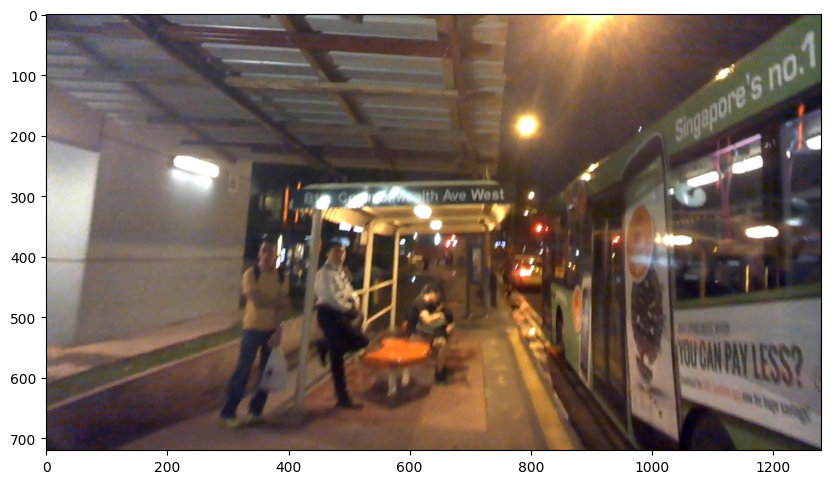

In [55]:
# 4. Declare the DecodeImage class to decode the image
decode_image = DecodeImage(img_mode='RGB', channel_first=False)
data = decode_image(data)

# 5. Print the shape of the decoded image and visualize the image
print("The shape of decoded image is ", data['image'].shape)

plt.figure(figsize=(10, 10))
plt.imshow(data['image'])
src_img = data['image']

**Label Code**

Analyze the label information in the txt file and save it in a unified format.

In [56]:
# Import DetLabelEncode from PaddleOCR
from ppocr.data.imaug.label_ops import DetLabelEncode

# 1. Declare the class for label decoding
decode_label = DetLabelEncode()

# 2. Print the label before decoding
print("The label before decode are: ", data['label'])

# 3. Label decoding
data = decode_label(data)
print("\n")

# 4. Print the decoded label
print("The polygon after decode are: ", data['polys'])
print("The text after decode are: ", data['texts'])


The label before decode are:  [{"transcription": "###", "points": [[427, 293], [469, 293], [468, 315], [425, 314]]}, {"transcription": "###", "points": [[480, 291], [651, 289], [650, 311], [479, 313]]}, {"transcription": "Ave", "points": [[655, 287], [698, 287], [696, 309], [652, 309]]}, {"transcription": "West", "points": [[701, 285], [759, 285], [759, 308], [701, 308]]}, {"transcription": "YOU", "points": [[1044, 531], [1074, 536], [1076, 585], [1046, 579]]}, {"transcription": "CAN", "points": [[1077, 535], [1114, 539], [1117, 595], [1079, 585]]}, {"transcription": "PAY", "points": [[1119, 539], [1160, 543], [1158, 601], [1120, 593]]}, {"transcription": "LESS?", "points": [[1164, 542], [1252, 545], [1253, 624], [1166, 602]]}, {"transcription": "Singapore's", "points": [[1032, 177], [1185, 73], [1191, 143], [1038, 223]]}, {"transcription": "no.1", "points": [[1190, 73], [1270, 19], [1278, 91], [1194, 133]]}]


AttributeError: module 'numpy' has no attribute 'bool'

# references

[doc-en](https://github.com/PaddlePaddle/PaddleOCR/tree/release/2.6/doc/doc_en)

[DB && DB++](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/algorithm_det_db_en.md)

[Text Detection](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/detection_en.md)

[OCR datasets](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/doc/doc_en/dataset/ocr_datasets_en.md)